# Practical Project 1 : Expectation Decider

In [1]:
pip install matplotlib-venn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
from math import comb

In [3]:
df = pd.read_csv("Expectation Decider.csv")

In [4]:
df

,student_id,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,1,11,75,Yes,80,Pass
1,2,13,79,Yes,70,Pass
2,3,16,76,Yes,78,Pass
3,4,13,91,Yes,77,Pass
4,5,18,88,Yes,82,Pass
...,...,...,...,...,...,...
195,196,7,62,Yes,64,Fail
196,197,6,59,No,39,Fail
197,198,4,53,Yes,49,Fail
198,199,12,68,Yes,59,Fail


In [5]:
df.head(5)

,student_id,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,1,11,75,Yes,80,Pass
1,2,13,79,Yes,70,Pass
2,3,16,76,Yes,78,Pass
3,4,13,91,Yes,77,Pass
4,5,18,88,Yes,82,Pass


In [6]:
len(df)

200

In [7]:
df.info

<bound method DataFrame.info of      student_id  study_hours  attendance group_discussion  \
0             1           11          75              Yes   
1             2           13          79              Yes   
2             3           16          76              Yes   
3             4           13          91              Yes   
4             5           18          88              Yes   
..          ...          ...         ...              ...   
195         196            7          62              Yes   
196         197            6          59               No   
197         198            4          53              Yes   
198         199           12          68              Yes   
199         200            7          75               No   

     previous_test_score final_exam_pass  
0                     80            Pass  
1                     70            Pass  
2                     78            Pass  
3                     77            Pass  
4                   

# What Is Probability ?
# Probability is the chance of something happening. It measures how likely or unlikely an event is.¶
----------------------------------------------------------------------------------------------------

# 1. Experiment
# Koi bhi activity ya process jiska outcome uncertain ho.
# Example:
# Competitive mathematics exam dena.
====================================================================================================

# 2. Outcome
# Experiment ka result.
# Example:
# Pass
# Fail
====================================================================================================

# 3. Sample Space (S)
# Saare possible outcomes ka collection.
# Example:
# S = {Pass, Fail}
====================================================================================================

# 4. Event
# Sample space ka ek subset ya specific outcome.
# Example:
# "Student pass kare."
====================================================================================================

# 5. Probability
# Kisi event ke hone ki likelihood ya chance.
# Example:
# P(Pass) = 0.60
====================================================================================================

# 6. Random Variable
# Ek numerical variable jo random experiment ke outcomes ko represent karta hai.
# Example:
# X = 3 randomly selected students me pass hone wale students ki sankhya.
====================================================================================================

# 7. Independent Events
# Do events jahan ek event ka result dusre event ko affect nahi karta.
# Example:
# Coin toss ke do alag toss.
====================================================================================================

# 8. Conditional Probability
# Jab ek event ke hone ki probability dusre event ke hone ki condition par nikali jati hai.

# Q3 Three probability event examples

In [8]:
a = len(df[(df["study_hours"] > 8) & (df["final_exam_pass"] == "Fail")])
p = a / len(df)
print(p)

0.155


In [9]:
a = len(df[(df["attendance"] > 75) & (df["final_exam_pass"] == "Pass")])

p = a / len(df)

print(p)

0.555


In [10]:
a = len(df[(df["group_discussion"] == "Yes") &
           (df["final_exam_pass"] == "Pass")])

p = a / len(df)

print(p)

0.46


# Types of Events

## Empirical Probability

### Empirical Probability actual observed data se calculate ki jati hai.

### Formula:
### P(E) = Number of favorable outcomes / Total number of outcomes

### Example:
### Probability that a student passes the final exam based on the dataset.



In [11]:
#Total students
total_students = len(df)

# Students who passed
passed_students = len(df[df["final_exam_pass"] == "Pass"])

# Empirical Probability
empirical_probability = passed_students / total_students

print("Passed Students =", passed_students)
print("Total Students =", total_students)
print("Empirical Probability of Passing =", empirical_probability)

Passed Students = 120
Total Students = 200
Empirical Probability of Passing = 0.6



## Theoretical Probability

### Theoretical Probability mathematical assumptions aur formulas ke basis par calculate ki jati hai.

### Formula:
### P(E) = Number of favorable outcomes / Total possible outcomes

### Example:
### If Pass and Fail are assumed equally likely, find the probability that exactly 2 out of 3 randomly selected students pass.

In [12]:


# Assume Pass and Fail are equally likely
p = 0.5

# Number of students selected
n = 3

# Exactly 2 students pass
x = 2

theoretical_probability = comb(n, x) * (p**x) * ((1-p)**(n-x))

print("Theoretical Probability =", theoretical_probability)

Theoretical Probability = 0.375


# Random Variable & Probability Distribution

## Define Random Variable

# Let X be the random variable representing the number of students who pass the final exam out of 3 randomly selected students.


In [15]:
total_students = len(df)

passed_students = len(df[df["final_exam_pass"] == "Pass"])

p = passed_students / total_students

print("P(Pass) =", p)

print("Random Variable X = Number of students passing among 3 randomly selected students")

P(Pass) = 0.6
Random Variable X = Number of students passing among 3 randomly selected students


# Construct Probability Distribution Table

In [24]:
# Random Variable:
# X = Number of students passing the final exam out of 3 randomly selected students

from scipy.stats import binom
import pandas as pd

# Number of selected students
n = 3

# Calculate probability of passing from dataset
total_pass = len(df[df["final_exam_pass"] == "Pass"])
total_students = len(df)

p = total_pass / total_students

print("Probability of Passing =", p)

# Possible values of X
x_values = [0, 1, 2, 3]

# Calculate probabilities using Binomial Distribution
probabilities = []

for x in x_values:
    prob = binom.pmf(x, n, p)
    probabilities.append(prob)

# Create Probability Distribution Table
distribution_table = pd.DataFrame({
    "X (Students Passing)": x_values,
    "P(X=x)": probabilities})

print("\nProbability Distribution Table:")
print(distribution_table)

# Mean of Random Variable
mean = sum(
    distribution_table["X (Students Passing)"] *
    distribution_table["P(X=x)"])

print("\nMean =", mean)

# Variance of Random Variable
variance = n * p * (1 - p)

print("Variance =", variance)

Probability of Passing = 0.6

Probability Distribution Table:
   X (Students Passing)  P(X=x)
0                     0   0.064
1                     1   0.288
2                     2   0.432
3                     3   0.216

Mean = 1.7999999999999998
Variance = 0.72


# Venn Diagram in Probability

In [19]:
# Students studying more than 8 hours/week
study_more_8 = len(df[df["study_hours"] > 8])

# Students attending more than 75% classes
attendance_more_75 = len(df[df["attendance"] > 75])

# Students satisfying both conditions
both_conditions = len(
    df[
        (df["study_hours"] > 8) &
        (df["attendance"] > 75)])

print("Study > 8 Hours =", study_more_8)
print("Attendance > 75% =", attendance_more_75)
print("Both Conditions =", both_conditions)

Study > 8 Hours = 151
Attendance > 75% = 131
Both Conditions = 119


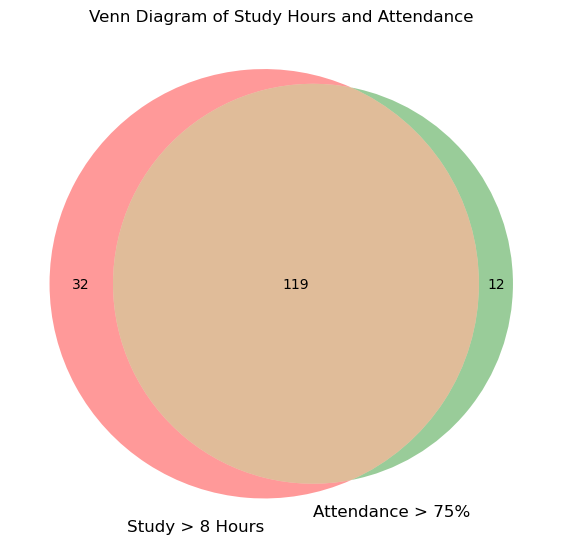

In [21]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

plt.figure(figsize=(7,7))

venn2(
    subsets=(
        study_more_8 - both_conditions,
        attendance_more_75 - both_conditions,
        both_conditions
    ),
    set_labels=(
        "Study > 8 Hours",
        "Attendance > 75%"))

plt.title("Venn Diagram of Study Hours and Attendance")

plt.show()

 # contingency table

In [22]:

contingency_table = pd.crosstab(
    df["group_discussion"],
    df["final_exam_pass"])

print("Contingency Table:")
print(contingency_table)

Contingency Table:
final_exam_pass   Fail  Pass
group_discussion            
No                  40    28
Yes                 40    92


# Joint Probability

In [23]:
joint_count = len(
    df[
        (df["group_discussion"] == "Yes") &
        (df["final_exam_pass"] == "Pass")])

total_students = len(df)

joint_probability = joint_count / total_students

print("Joint Probability =", joint_probability)

Joint Probability = 0.46


# Margin Probaility 

In [33]:
pass_count = len(
    df[df["final_exam_pass"] == "Pass"]
)

marginal_probability = pass_count / total_students

print("Marginal Probability =", marginal_probability)

Marginal Probability = 0.6


# Condition probability

In [39]:
gd_yes = len(df[df["group_discussion"] == "Yes"])
pass_and_gd = len(df[(df["group_discussion"] == "Yes") & (df["final_exam_pass"] == "pass")])
condition_probability = pass_and_gd / gd_yes
print ("Conditional Probability=",conditional_probability)

Conditional Probability= 0.696969696969697


# Understanding Relationships


## Interpretation of Conditional Probability

# Conditional probability tells us the probability that a student passes the final exam given that the student participates in group discussions.

# Formula:

# P(Pass | Group Discussion)

# Intuition:

# Instead of looking at all students, we only look at students who participate in group discussions.

# Among those students, we calculate how many passed the final exam.

# For example, if:

# P(Pass) = 0.60

# and

# P(Pass | Group Discussion) = 0.73

# This means:

# - The overall pass rate is 60%.
# - Among students who participate in group discussions, the pass rate increases to 73%.

# Therefore, students who participate in group discussions have a higher chance of passing the exam.


In [40]:
# Overall probability of passing
p_pass = len(df[df["final_exam_pass"] == "Pass"]) / len(df)

# Conditional probability of passing given group discussion participation
p_pass_given_gd = (
    len(
        df[
            (df["group_discussion"] == "Yes") &
            (df["final_exam_pass"] == "Pass")])/len(df[df["group_discussion"] == "Yes"]))

print("P(Pass) =", round(p_pass,3))
print("P(Pass | Group Discussion) =", round(p_pass_given_gd,3))

P(Pass) = 0.6
P(Pass | Group Discussion) = 0.697


In [41]:
if round(p_pass,3) == round(p_pass_given_gd,3):
    print("Events are Independent")
else:
    print("Events are Dependent")

Events are Dependent


# Bayes Therom appliaction 

In [43]:
# Given probabilities

P_H_given_P = 0.70      # High Attendance given Pass

P_P = 0.60             # Probability of Pass

P_H = 0.60             # Probability of High Attendance

# Bayes Theorem

P_P_given_H = (P_H_given_P * P_P) / P_H

print("P(Pass | High Attendance) =", round(P_P_given_H, 2))
print("Percentage =", round(P_P_given_H * 100, 2), "%")

P(Pass | High Attendance) = 0.7
Percentage = 70.0 %
